# 05 — Exploratory Data Analysis

**Different from 01-04: no CONFIG/Engine architecture here.** 01-04 apply the same logic across multiple datasets in a loop; 05 is three research questions, each with its own custom charts and interpretation — forcing a CONFIG/Engine split here would be structure for its own sake, not because the problem calls for it.

**Scope:** the original proposal had 4 research questions. The 4th (which audio features best predict a chart hit) is a modeling question, handled in 06. This stage answers the first three, each carried through one full pass — subset the data, describe it, visualize it, break it down by decade, and state what the numbers show:
1. How has the genre distribution of Billboard Hot 100 songs changed across six decades?
2. Does musical mood (valence) decline during periods of social unrest, like the Vietnam War era or post-9/11?
3. Does the rise of speechiness reflect Hip-Hop going mainstream?

## Architecture

No CONFIG/Engine split here — each RQ needs its own custom charts and interpretation, so forcing a shared engine onto three different questions would be structure for its own sake. What *is* shared is the analytical pattern:

| | |
|---|---|
| **Shared base** | `analysis_base` (Step 1) — built once, every RQ subsets from it |
| **Per-RQ pattern** | Subset the relevant rows → describe the distribution → visualize it → break it down by decade → state what the numbers show |
| **Shared helper** | `add_phase_backgrounds()` (Step 8) — the one piece of logic genuinely reused across multiple charts (RQ2's trend charts), pulled into a function even though the rest of 05 doesn't use CONFIG/Engine |

**Scope note:** each RQ below stops at its first full pass through this pattern — the reusable EDA workflow, not this dataset's deepest possible investigation. A dataset-specific deep dive (e.g. testing one RQ's premise against several alternative explanations) is a natural next step once the first pass raises a specific question, but isn't part of the core process every dataset needs.

## Step Blueprint

| Step | What It Does | Question Answered |
|------|------|------|
| **Step 1** | Build `analysis_base` | The shared base dataset every RQ subsets from |
| **Step 2** | RQ1 subset: genre-tagged records | Which rows actually have a genre tag to analyze? |
| **Step 3** | Genre distribution overview | How many songs fall into each genre, overall? |
| **Step 4** | Genre distribution by decade | How has that mix shifted across six decades? |
| **Step 5** | Visualization | Stacked bar + line chart of the decade shift |
| **Step 6** | Key observations | What does the shift actually show, and what's the coverage caveat? |
| **Step 7** | RQ2 setup: yearly feature averages | Year-by-year averages for 5 audio features |
| **Step 8** | Shared phase-background helper | One function reused by all 3 of RQ2's trend charts |
| **Step 9** | Five-feature trend chart | How do all 5 features move together over 60 years? |
| **Step 10** | Valence alone, three phases | Isolate valence's own trajectory |
| **Step 11** | Valence vs. Energy divergence | Where do the two features start pulling apart? |
| **Step 12** | Low-valence song sample | What do the lowest-valence years' songs actually look like? |
| **Step 13** | Key observations | Verified numbers; why the divergence marker sits at 1985 |
| **Figure A** | Sociopolitical events overlay | Does social unrest's timing actually line up with the mood decline? |
| **Step 14** | RQ2 wrap-up: features by decade | Summary table across all 5 features |
| **Step 15** | RQ3 setup: speechiness averages | Yearly/decade speechiness numbers |
| **Step 16** | Long-term speechiness trend | Chart with Golden Age of Hip-Hop marked |
| **Step 17** | Comparison by decade | Bar chart, decade over decade |
| **Step 18** | Comparison by genre | Which genres are the most "speech-like"? |
| **Step 19** | Genre bar chart | Hip-Hop highlighted against the rest |
| **Step 20** | Hip-Hop vs. other genres, by decade | Does the gap hold across all six decades? |
| **Step 21** | RQ3 wrap-up | Corrected Hip-Hop ratio (3.86x), limitations |

## Step 1 — Load the Joined Dataset, Build `analysis_base`

Read the joined dataset, filter to 1960-2019 with a successful audio-feature match (`target` not null), compute `decade`. This is the shared base dataset every RQ below builds on — built once.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

joined = pd.read_pickle('../Data/D1_D2_D3_joined.pkl')
print(f'Total observations: {len(joined):,}')

# Build analysis_base -- the shared base dataset for all 3 RQs
analysis_base = joined.copy()
analysis_base['year'] = analysis_base['date'].dt.year
analysis_base = analysis_base[
    (analysis_base['year'] >= 1960) & (analysis_base['year'] <= 2019)
    & (analysis_base['target'].notna())
].copy()
analysis_base['decade'] = (analysis_base['year'] // 10 * 10).astype(str) + 's'

print(f"\nAnalysis dataset (1960-2019, D2 matched):")
print(f"Total observations: {len(analysis_base):,}")
print(f"Year range: {analysis_base['year'].min()} - {analysis_base['year'].max()}")
print(f"\nDecade distribution:")
print(analysis_base['decade'].value_counts().sort_index().to_string())

Total observations: 330,087



Analysis dataset (1960-2019, D2 matched):
Total observations: 262,737
Year range: 1960 - 2019

Decade distribution:
decade
1960s    36826
1970s    40933
1980s    44945
1990s    42576
2000s    48301
2010s    49156


## RQ1 — How has the genre distribution of Billboard Hot 100 songs changed across decades?

*Same shape as every RQ below: subset the data → describe it → visualize it → break it down by decade → state what the numbers show.*

### Step 2 — RQ1 Subset: Genre-Tagged Records Only

In [2]:
genre_base = analysis_base[analysis_base['genre'].notna()].copy()

print(f'Genre analysis subset count: {len(genre_base):,}')
print(f'Coverage: {round(len(genre_base) / len(analysis_base) * 100, 2)}% of analysis_base')
print(f'\nDecade coverage:')
print(genre_base['decade'].value_counts().sort_index().to_string())

Genre analysis subset count: 44,149
Coverage: 16.8% of analysis_base

Decade coverage:
decade
1960s    5202
1970s    6134
1980s    8495
1990s    6306
2000s    9009
2010s    9003


### Step 3 — Genre Distribution Overview

In [3]:
genre_counts = genre_base['genre'].value_counts()
print('Genre Distribution Overview')
print(genre_counts.to_string())

Genre Distribution Overview
genre
pop        27617
rock        7507
country     5243
blues       1644
jazz        1084
hip hop      895
reggae       159


### Step 4 — Genre Distribution by Decade (%)

In [4]:
genre_decade = (
    genre_base.groupby(['decade', 'genre']).size()
    .rename('n').reset_index()
)
genre_decade['pct'] = genre_decade.groupby('decade')['n'].transform(lambda s: round(s / s.sum() * 100, 2))

pivot = genre_decade.pivot(index='genre', columns='decade', values='pct').fillna(0)
print('Genre Distribution (%) by Decade')
print(pivot.to_string())

Genre Distribution (%) by Decade
decade   1960s  1970s  1980s  1990s  2000s  2010s
genre                                            
blues    15.09   7.89   2.72   1.09   0.61   0.22
country   8.09  15.16   8.32   6.47  15.38  15.45
hip hop   0.00   0.00   0.33   7.66   3.12   1.14
jazz      6.40   8.17   2.72   0.27   0.00   0.02
pop      61.36  42.01  51.19  65.13  70.31  78.40
reggae    0.00   0.00   0.46   1.25   0.00   0.46
rock      9.05  26.77  34.26  18.13  10.58   4.31


### Step 5 — Visualization: Stacked Bar + Line Chart

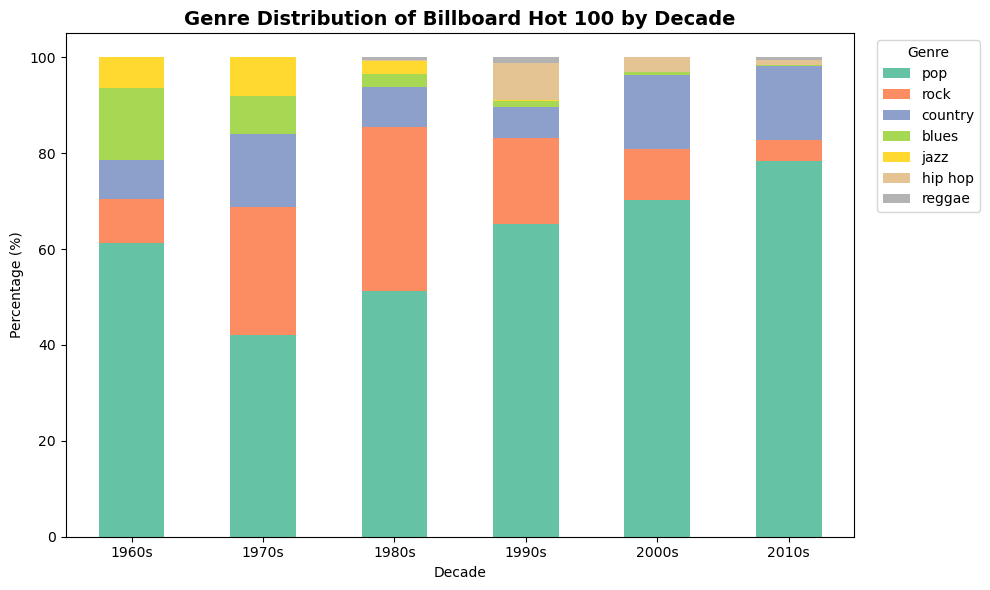

[SAVED] rq1_genre_stacked_bar.png


In [5]:
decade_order = sorted(genre_decade['decade'].unique())
genre_order = genre_counts.index.tolist()

stacked = genre_decade.pivot(index='decade', columns='genre', values='pct').reindex(decade_order)[genre_order]

fig, ax = plt.subplots(figsize=(10, 6))
stacked.plot(kind='bar', stacked=True, ax=ax, colormap='Set2')
ax.set_title('Genre Distribution of Billboard Hot 100 by Decade', fontsize=14, fontweight='bold')
ax.set_xlabel('Decade')
ax.set_ylabel('Percentage (%)')
ax.legend(title='Genre', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../Data/rq1_genre_stacked_bar.png', dpi=120)
plt.show()
print('[SAVED] rq1_genre_stacked_bar.png')

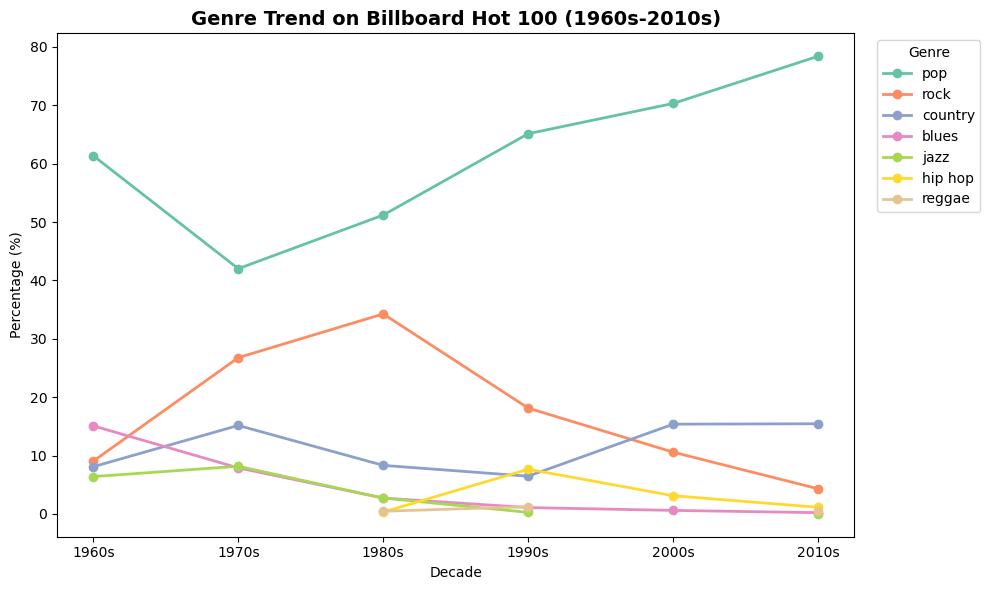

[SAVED] rq1_genre_line.png


In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.Set2.colors
for i, genre in enumerate(genre_order):
    series = stacked[genre]
    ax.plot(decade_order, series.values, marker='o', linewidth=2, label=genre, color=colors[i % len(colors)])

ax.set_title('Genre Trend on Billboard Hot 100 (1960s-2010s)', fontsize=14, fontweight='bold')
ax.set_xlabel('Decade')
ax.set_ylabel('Percentage (%)')
ax.legend(title='Genre', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('../Data/rq1_genre_line.png', dpi=120)
plt.show()
print('[SAVED] rq1_genre_line.png')

### Step 6 — Key Observations

Genre distribution over six decades: **Pop climbs steadily**, from 61.4% (1960s) to 78.4% (2010s) — a march toward dominating the chart. **Rock peaked at 26-34%** in the 70s-80s before falling to 4.3% by the 2010s. **Blues and Jazz**, each around 15% and 6% in the 1960s, are both near 0% by the 2010s. **Hip-Hop only shows a 7.6% peak, in the 1990s alone** — a lot of Hip-Hop tracks likely get classified as Pop instead, a limitation picked up again in RQ3 using speechiness as a supplementary signal rather than force-correcting the genre tag here.

**A real coverage caveat, checked rather than glossed over:** genre coverage isn't evenly spread across decades — roughly 14-15% for the 1960s/1970s/1990s, but 18-19% for the 1980s/2000s/2010s, a 4-5 point gap. That means the cross-decade comparison above is partly shaped by which decades happen to have better genre coverage, not a perfectly even sample. Broad directional trends (Pop rising, Rock declining) are usually robust enough to survive a gap this size, but it's a real limitation worth stating plainly rather than assuming the sample is even.

## RQ2 — Does musical mood (valence) decline during periods of social unrest, such as the Vietnam War era or post-9/11?

*Same five-step shape as RQ1 — subset, describe, visualize, decade-breakdown, state the finding — applied to a new question.*

### Step 7 — Setup: Yearly Averages of 5 Audio Features

In [7]:
features_yearly = (
    analysis_base.groupby('year')[['valence', 'energy', 'danceability', 'acousticness', 'speechiness']]
    .mean()
    .reset_index()
)

valence_yearly = features_yearly[['year', 'valence']].rename(columns={'valence': 'avg_valence'})

print('Yearly feature averages (first 5 rows):')
print(features_yearly.head().to_string(index=False))
print()
print(f"1960 avg valence: {features_yearly.loc[features_yearly['year']==1960, 'valence'].values[0]:.3f}")
print(f"2019 avg valence: {features_yearly.loc[features_yearly['year']==2019, 'valence'].values[0]:.3f}")

Yearly feature averages (first 5 rows):
 year  valence   energy  danceability  acousticness  speechiness
 1960 0.650061 0.453418      0.517154      0.677832     0.046144
 1961 0.675237 0.481565      0.530255      0.650473     0.051888
 1962 0.678917 0.479757      0.543771      0.641183     0.056948
 1963 0.685129 0.510997      0.537572      0.599356     0.052581
 1964 0.695510 0.549409      0.535731      0.555046     0.048104

1960 avg valence: 0.650
2019 avg valence: 0.503


### Step 8 — Shared Helper: Three-Era Phase Backgrounds

Three of this section's charts share the same "three-phase background shading + divider lines" — pulled into one function, `add_phase_backgrounds(ax)`, called by all three. Extending CONFIG/Engine thinking even though 05 as a whole doesn't use that architecture: genuinely-repeated logic still gets extracted, just not for the sake of extracting.

In [8]:
PHASES = [
    (1960, 1979, '#FFD700', 'Phase 1\nDisco Era', '#B8860B'),
    (1980, 1999, '#FF6B6B', 'Phase 2\nPost-Disco & Rock', '#CC0000'),
    (2000, 2019, '#4A90D9', 'Phase 3\nHip-Hop & Digital', '#1A5276'),
]

def add_phase_backgrounds(ax, label_y=0.90, alpha=0.06):
    """Shared three-era background shading + labels + divider lines, used by every
    RQ2 chart, instead of repeating the same shading block three times."""
    for start, end, color, label, text_color in PHASES:
        ax.axvspan(start, end, color=color, alpha=alpha, zorder=0)
        mid = (start + end) / 2
        ax.text(mid, label_y, label, ha='center', fontsize=10, fontweight='bold',
                color=text_color, transform=ax.get_xaxis_transform())
    ax.axvline(1980, color='gray', linewidth=0.6, alpha=0.5)
    ax.axvline(2000, color='gray', linewidth=0.6, alpha=0.5)

### Step 9 — Five-Feature Trend, Three Phases

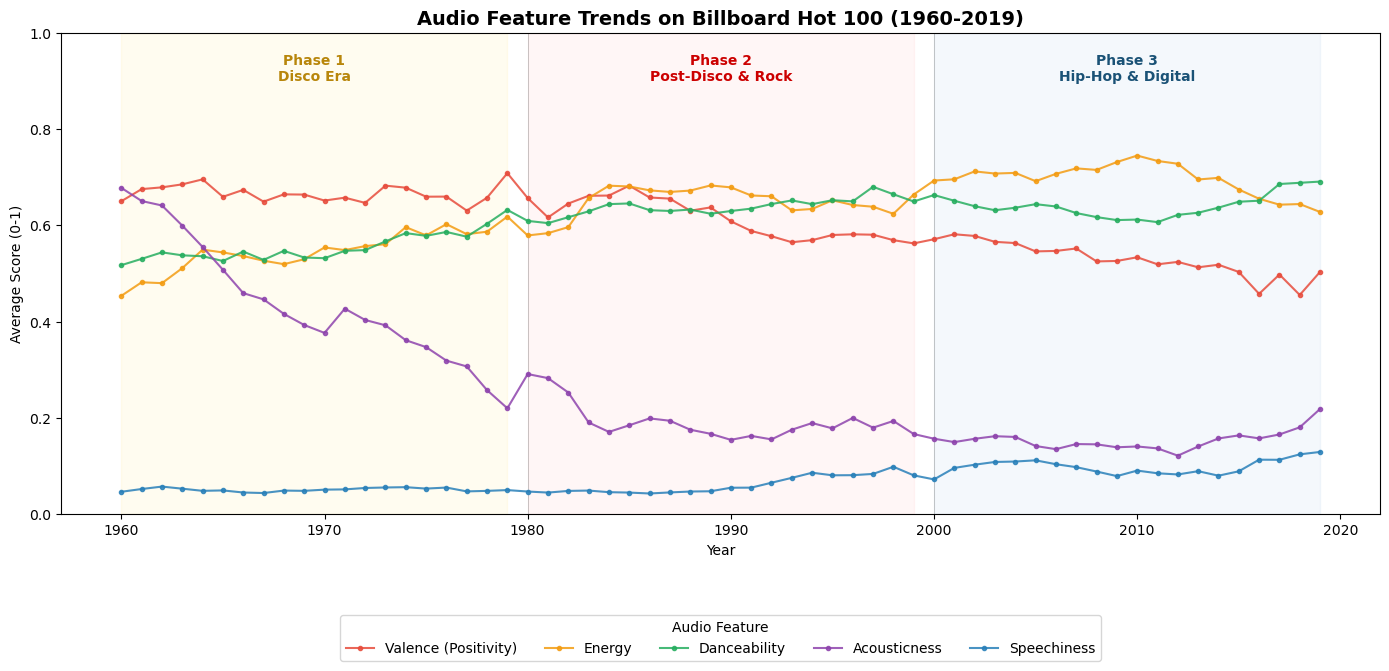

[SAVED] rq2_five_features_trend.png


In [9]:
fig, ax = plt.subplots(figsize=(14, 7))
add_phase_backgrounds(ax, label_y=0.90)

feature_colors = {
    'valence': '#E74C3C', 'energy': '#F39C12', 'danceability': '#27AE60',
    'acousticness': '#8E44AD', 'speechiness': '#2980B9',
}
feature_labels = {
    'valence': 'Valence (Positivity)', 'energy': 'Energy', 'danceability': 'Danceability',
    'acousticness': 'Acousticness', 'speechiness': 'Speechiness',
}
for feat, color in feature_colors.items():
    ax.plot(features_yearly['year'], features_yearly[feat], color=color, linewidth=1.5,
            marker='o', markersize=3, alpha=0.85, label=feature_labels[feat])

ax.set_ylim(0, 1)
ax.set_title('Audio Feature Trends on Billboard Hot 100 (1960-2019)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Average Score (0-1)')
# Legend moved below the plot (not to the right) so this chart's plot area is the
# same width as Step 11's divergence chart -- lets the two stacked charts' year-axes
# line up visually when compared (Vivian's request, 2026/08/19).
ax.legend(title='Audio Feature', loc='lower center', bbox_to_anchor=(0.5, -0.32), ncol=5)
plt.tight_layout()
plt.savefig('../Data/rq2_five_features_trend.png', dpi=120)
plt.show()
print('[SAVED] rq2_five_features_trend.png')

### Step 10 — Valence Alone, Three Phases

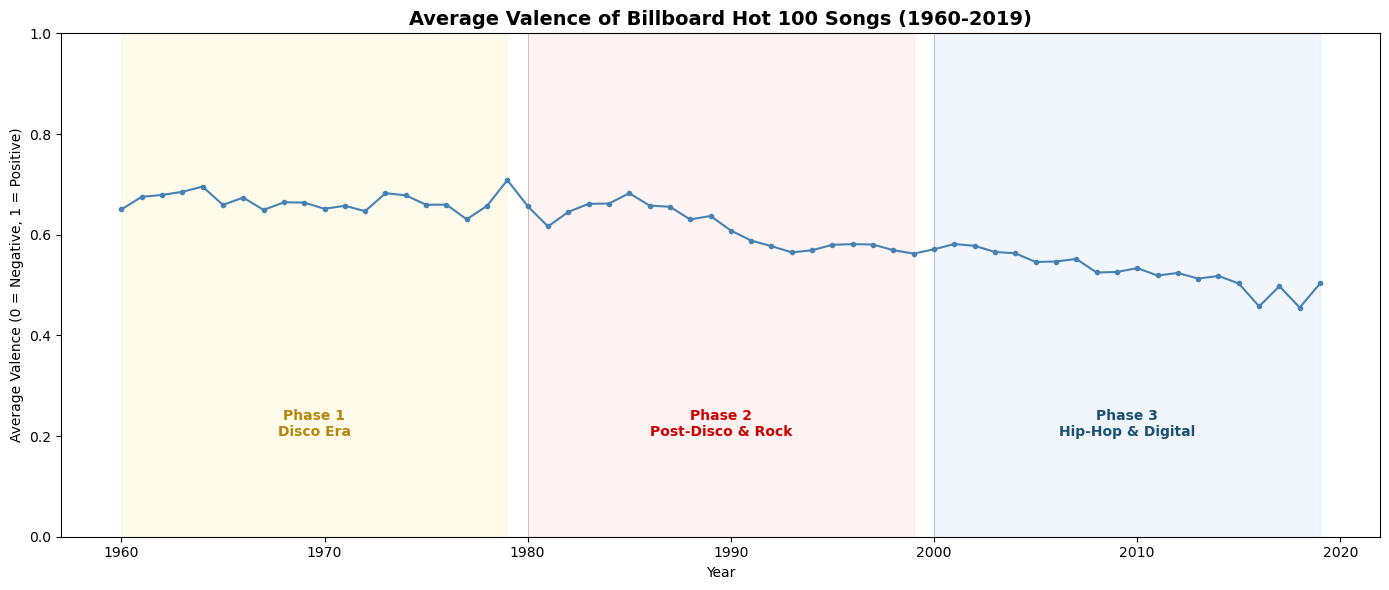

[SAVED] rq2_valence_trend.png


In [10]:
fig, ax = plt.subplots(figsize=(14, 6))
add_phase_backgrounds(ax, label_y=0.2, alpha=0.08)

ax.plot(valence_yearly['year'], valence_yearly['avg_valence'], color='steelblue', linewidth=1.5,
        marker='o', markersize=3)
ax.set_ylim(0, 1)
ax.set_title('Average Valence of Billboard Hot 100 Songs (1960-2019)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Average Valence (0 = Negative, 1 = Positive)')
plt.tight_layout()
plt.savefig('../Data/rq2_valence_trend.png', dpi=120)
plt.show()
print('[SAVED] rq2_valence_trend.png')

### Step 11 — Valence vs. Energy Divergence

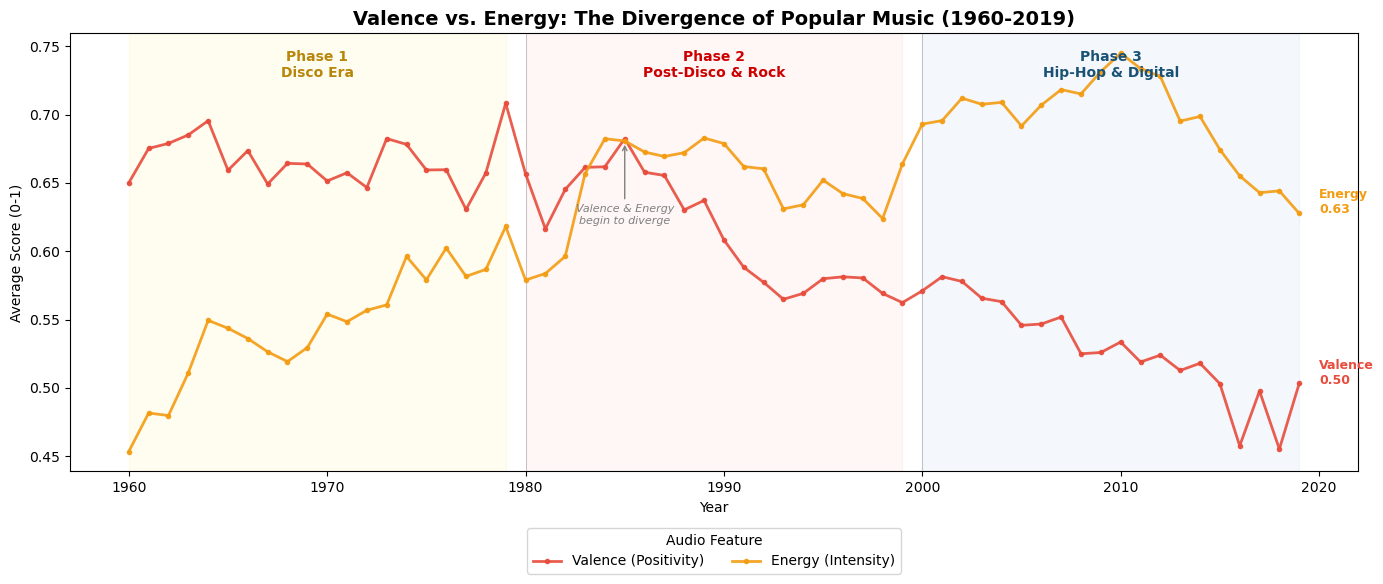

[SAVED] rq2_valence_energy_divergence.png

End-of-period values -- Valence: 0.503, Energy: 0.628


In [11]:
fig, ax = plt.subplots(figsize=(14, 6))
add_phase_backgrounds(ax, label_y=0.90, alpha=0.06)

ax.plot(features_yearly['year'], features_yearly['valence'], color='#E74C3C', linewidth=2,
        marker='o', markersize=3, alpha=0.9, label='Valence (Positivity)')
ax.plot(features_yearly['year'], features_yearly['energy'], color='#F39C12', linewidth=2,
        marker='o', markersize=3, alpha=0.9, label='Energy (Intensity)')

# 1985 is Valence's local peak *within Phase 2* (0.682) -- the global peak is actually
# 1979, but that year still sits inside Phase 1's shading, not Phase 2. From 1985
# onward Valence enters a long, uninterrupted decline while Energy keeps climbing.
# (An earlier draft anchored this at the global peak, 1979 -- moved to 1985 since
# 1979 still sits visually inside Phase 1's shading.)
ax.annotate('Valence & Energy\nbegin to diverge', xy=(1985, 0.68), xytext=(1985, 0.62),
            fontsize=8, color='gray', style='italic', ha='center',
            arrowprops=dict(arrowstyle='->', color='gray'))

end_valence = features_yearly.loc[features_yearly['year']==2019, 'valence'].values[0]
end_energy = features_yearly.loc[features_yearly['year']==2019, 'energy'].values[0]
ax.text(2020, end_valence, f'Valence\n{end_valence:.2f}', fontsize=9, color='#E74C3C', fontweight='bold')
ax.text(2020, end_energy, f'Energy\n{end_energy:.2f}', fontsize=9, color='#F39C12', fontweight='bold')

ax.set_title('Valence vs. Energy: The Divergence of Popular Music (1960-2019)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Average Score (0-1)')
ax.legend(title='Audio Feature', loc='lower center', bbox_to_anchor=(0.5, -0.25), ncol=2)
plt.tight_layout()
plt.savefig('../Data/rq2_valence_energy_divergence.png', dpi=120)
plt.show()
print('[SAVED] rq2_valence_energy_divergence.png')
print(f"\nEnd-of-period values -- Valence: {end_valence:.3f}, Energy: {end_energy:.3f}")

In [12]:
# Filter to 1979-1990
df_80s = features_yearly[(features_yearly['year'] >= 1979) & (features_yearly['year'] <= 1990)].copy()

# Year-over-year change in Valence
df_80s['valence_drop'] = df_80s['valence'].diff()

# Year-over-year change in Energy
df_80s['energy_rise'] = df_80s['energy'].diff()

print("=== 1979-1990 Valence and Energy Year-over-Year Change ===")
print(df_80s[['year', 'valence', 'valence_drop', 'energy', 'energy_rise']].to_string(index=False))

=== 1979-1990 Valence and Energy Year-over-Year Change ===
 year  valence  valence_drop   energy  energy_rise
 1979 0.708338           NaN 0.618115          NaN
 1980 0.656650     -0.051688 0.578903    -0.039212
 1981 0.616352     -0.040297 0.583687     0.004784
 1982 0.645240      0.028888 0.596238     0.012551
 1983 0.661361      0.016121 0.656713     0.060475
 1984 0.661830      0.000469 0.682329     0.025616
 1985 0.682424      0.020593 0.680722    -0.001607
 1986 0.657828     -0.024596 0.672622    -0.008099
 1987 0.655444     -0.002383 0.669360    -0.003262
 1988 0.630277     -0.025167 0.672152     0.002792
 1989 0.637182      0.006905 0.682861     0.010709
 1990 0.608286     -0.028896 0.678818    -0.004044


### Step 12 — Low-Valence Song Sample (2016, 2018)

In [13]:
low_valence_songs = (
    analysis_base[analysis_base['year'].isin([2016, 2018])]
    .drop_duplicates(subset=['song_clean', 'artist_clean'])
    .sort_values('valence')
    [['year', 'song_clean', 'artist_clean', 'valence', 'energy']]
)
print(low_valence_songs.head(10).to_string(index=False))

 year        song_clean               artist_clean  valence  energy
 2016                 9                      drake   0.0379   0.712
 2018           topanga               trippie redd   0.0390   0.615
 2016           selfish                   pnb rock   0.0399   0.600
 2016           forward                    beyonce   0.0498   0.133
 2018          delicate               taylor swift   0.0499   0.404
 2016    summer sixteen                      drake   0.0541   0.460
 2018 biggest alley oop                      quavo   0.0548   0.408
 2018        stargazing               travis scott   0.0564   0.789
 2018     outside today youngboy never broke again   0.0585   0.666
 2016   come and see me              partynextdoor   0.0589   0.347


### Step 13 — Key Observations

- **Valence declined:** 0.650 (1960) → 0.503 (2019), about 22.6%
- **Energy rose, diverging from Valence:** 0.453 (1960) → 0.628 (2019)
- **2016 and 2018 are the two lowest points** in the whole 1960-2019 valence series — Step 12's sample above shows what those low-valence tracks actually look like

**An engineering habit worth calling out:** every number and label on these charts (`f'{end_valence:.2f}'`, the annotation coordinates, etc.) is computed directly from the data at render time, never hand-typed into the code. A hard-coded label silently goes stale the moment the underlying data changes — computing it live means the chart can never drift out of sync with the numbers behind it.

**A coverage caveat that does NOT apply here:** valence and energy both come from the same audio-feature source `analysis_base` is already filtered on, so this sample's coverage is 100% — unlike RQ1's genre analysis, which only covers 14-19% of rows. Confirmed by the filter logic itself, not assumed.

**The "Valence & Energy begin to diverge" annotation on Step 11's chart is anchored at 1985** — Valence's local peak within Phase 2 (0.682), just after which it enters a 15-year uninterrupted decline (down to 0.562 by 1999). The global valence peak is actually 1979, but that year visually sits inside Phase 1's shading rather than Phase 2 — 1985 better represents where the *sustained* divergence from Energy actually begins.

### Figure A — Testing RQ2's Premise: Sociopolitical Events Overlay

Layers a real historical-events timeline onto the Valence vs. Energy divergence chart — the most direct way to test RQ2's actual question: does social unrest track with a mood decline?

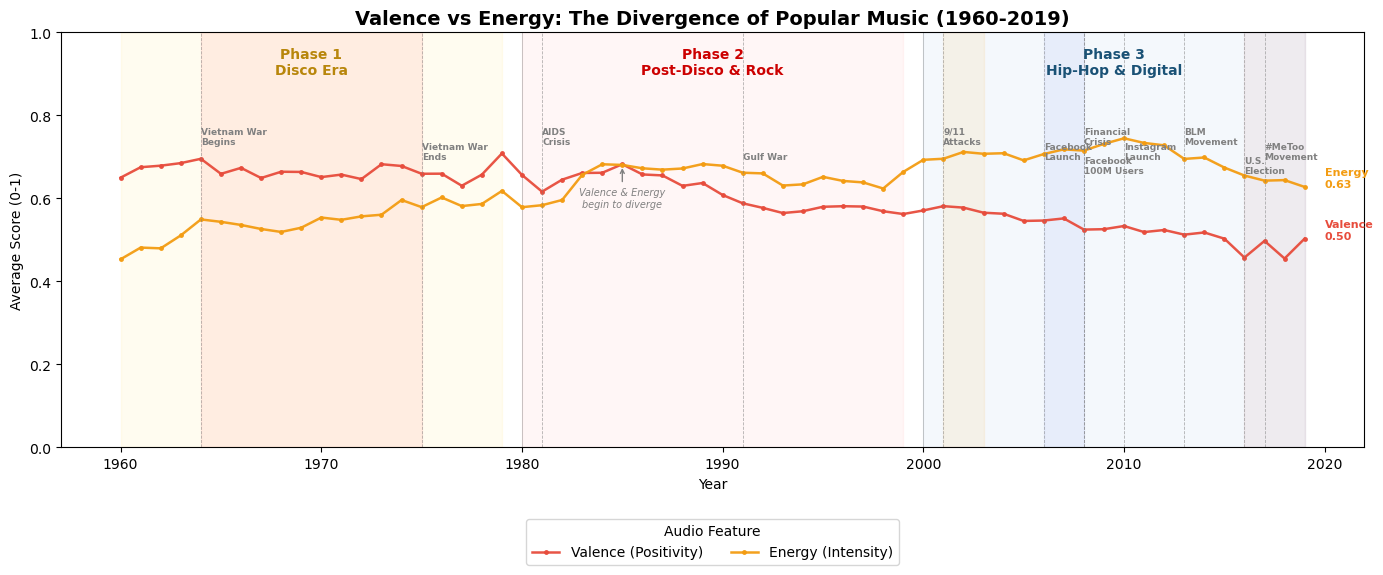

[SAVED] rq2_figureA_sociopolitical.png


In [14]:
events_ve = [
    (1964, 'Vietnam War\nBegins', 'red', 0.730),
    (1975, 'Vietnam War\nEnds', 'red', 0.695),
    (1981, 'AIDS\nCrisis', 'purple', 0.730),
    (1991, 'Gulf War', 'brown', 0.695),
    (2001, '9/11\nAttacks', 'darkorange', 0.730),
    (2006, 'Facebook\nLaunch', 'royalblue', 0.695),
    (2008, 'Financial\nCrisis', 'darkblue', 0.730),
    (2008, 'Facebook\n100M Users', 'royalblue', 0.660),
    (2010, 'Instagram\nLaunch', 'deeppink', 0.695),
    (2013, 'BLM\nMovement', 'darkgreen', 0.730),
    (2016, 'U.S.\nElection', 'darkred', 0.660),
    (2017, '#MeToo\nMovement', 'hotpink', 0.695),
]

fig, ax = plt.subplots(figsize=(14, 6))
add_phase_backgrounds(ax, label_y=0.90, alpha=0.06)

# Event-specific highlight bands
ax.axvspan(2006, 2008, color='royalblue', alpha=0.07)
ax.axvspan(2001, 2003, color='orange', alpha=0.08)
ax.axvspan(1964, 1975, color='red', alpha=0.06)
ax.axvspan(2016, 2019, color='darkred', alpha=0.05)

ax.plot(features_yearly['year'], features_yearly['valence'], color='#E74C3C', linewidth=1.8,
        marker='o', markersize=2.5, alpha=0.95, label='Valence (Positivity)')
ax.plot(features_yearly['year'], features_yearly['energy'], color='#F39C12', linewidth=1.8,
        marker='o', markersize=2.5, alpha=0.95, label='Energy (Intensity)')

for year, label, color, y_pos in events_ve:
    ax.axvline(year, color='gray', linestyle='--', linewidth=0.6, alpha=0.6)
    ax.text(year, y_pos, label, color='gray', fontsize=6.5, fontweight='bold', ha='left')

# 1985 is Valence's local peak *within Phase 2* (0.682) -- see Step 13 for why this
# replaced 1979 (global peak, but still visually inside Phase 1's shading).
ax.annotate('Valence & Energy\nbegin to diverge', xy=(1985, 0.68), xytext=(1985, 0.58),
            fontsize=7, color='gray', style='italic', ha='center',
            arrowprops=dict(arrowstyle='->', color='gray'))
ax.text(2020, end_valence, f'Valence\n{end_valence:.2f}', fontsize=8, color='#E74C3C', fontweight='bold')
ax.text(2020, end_energy, f'Energy\n{end_energy:.2f}', fontsize=8, color='#F39C12', fontweight='bold')

ax.set_ylim(0, 1)
ax.set_title('Valence vs Energy: The Divergence of Popular Music (1960-2019)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Average Score (0-1)')
ax.legend(title='Audio Feature', loc='lower center', bbox_to_anchor=(0.5, -0.3), ncol=2)
plt.tight_layout()
plt.savefig('../Data/rq2_figureA_sociopolitical.png', dpi=120)
plt.show()
print('[SAVED] rq2_figureA_sociopolitical.png')

**The timing doesn't line up cleanly.** The clearest valence crash in the whole series starts in 1980, but the AIDS crisis wasn't formally announced until June 1981 — the event postdates the mood shift it might otherwise seem to explain. None of the other overlaid events (Vietnam War, Gulf War, 9/11, the 2008 financial crisis) line up convincingly with a valence dip either.

**Honest conclusion:** RQ2's original hypothesis (social unrest → declining mood) doesn't hold up well against a direct visual test. Valence does decline substantially from 1960 to 2019, but the timing argues against social/political events being the driver — a deeper investigation into what actually explains the shift (music-industry trends, changing production styles, listener taste) would need more evidence than a straightforward event overlay, and is a natural next question rather than one this stage tries to force an answer to.

### Step 14 — RQ2 Wrap-Up: Audio Features by Decade

In [15]:
decade_summary_rq2 = (
    analysis_base.groupby('decade')[['valence', 'energy', 'danceability', 'acousticness', 'speechiness']]
    .mean().round(3)
)
decade_summary_rq2['n'] = analysis_base.groupby('decade').size()
print(decade_summary_rq2.to_string())

        valence  energy  danceability  acousticness  speechiness      n
decade                                                                 
1960s     0.670   0.514         0.534         0.533        0.049  36826
1970s     0.664   0.579         0.577         0.338        0.052  40933
1980s     0.651   0.648         0.627         0.210        0.046  44945
1990s     0.578   0.649         0.650         0.175        0.076  42576
2000s     0.555   0.708         0.636         0.149        0.097  48301
2010s     0.502   0.684         0.647         0.158        0.099  49156


## RQ3 — Does the rise of speechiness in popular music reflect the mainstreaming of Hip-Hop?

*Same shape a third time — the pattern doesn't change, only the question does.*

### Step 15 — Yearly / Decade Speechiness Averages

In [16]:
speechiness_yearly = analysis_base.groupby('year')['speechiness'].mean().reset_index(name='avg_speechiness')
speechiness_decade = (
    analysis_base.groupby('decade')['speechiness'].mean().round(4).reset_index(name='avg_speechiness')
)
speechiness_decade['n'] = analysis_base.groupby('decade').size().values

print(f"Year range: {speechiness_yearly['year'].min()} - {speechiness_yearly['year'].max()}")
print()
print(speechiness_decade.to_string(index=False))

Year range: 1960 - 2019

decade  avg_speechiness     n
 1960s           0.0489 36826
 1970s           0.0519 40933
 1980s           0.0459 44945
 1990s           0.0757 42576
 2000s           0.0967 48301
 2010s           0.0993 49156


### Step 16 — Long-Term Speechiness Trend (with Golden Age of Hip-Hop Marked)

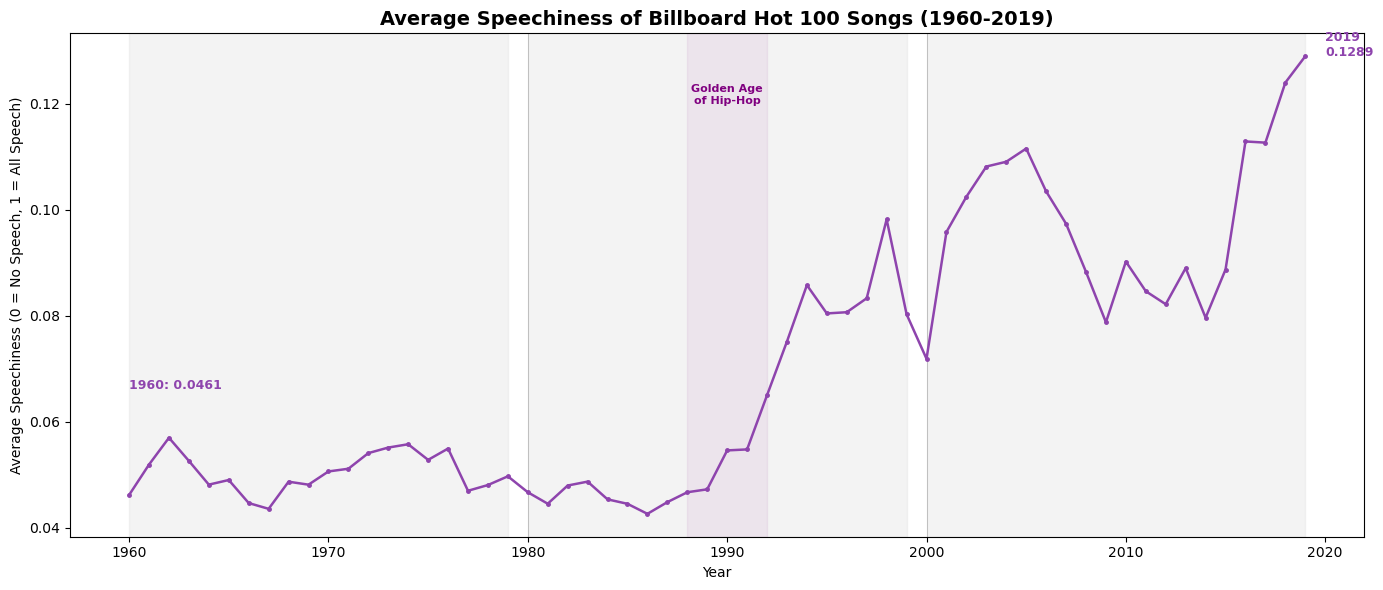

[SAVED] rq3_speechiness_trend.png


In [17]:
fig, ax = plt.subplots(figsize=(14, 6))
for start, end, _, _, _ in PHASES:
    ax.axvspan(start, end, color='lightgray', alpha=0.25, zorder=0)
ax.axvline(1980, color='gray', linewidth=0.6, alpha=0.5)
ax.axvline(2000, color='gray', linewidth=0.6, alpha=0.5)

# Golden Age of Hip-Hop highlight (1988-1992)
ax.axvspan(1988, 1992, color='purple', alpha=0.06)
ax.text(1990, 0.120, 'Golden Age\nof Hip-Hop', color='purple', fontsize=8, fontweight='bold', ha='center')

ax.plot(speechiness_yearly['year'], speechiness_yearly['avg_speechiness'], color='#8E44AD', linewidth=1.8, marker='o', markersize=2.5)

start_speech = speechiness_yearly.loc[speechiness_yearly['year']==1960, 'avg_speechiness'].values[0]
end_speech = speechiness_yearly.loc[speechiness_yearly['year']==2019, 'avg_speechiness'].values[0]
ax.text(1960, start_speech + 0.02, f'1960: {start_speech:.4f}', color='#8E44AD', fontsize=9, fontweight='bold', ha='left')
ax.text(2020, end_speech, f'2019\n{end_speech:.4f}', color='#8E44AD', fontsize=9, fontweight='bold')

ax.set_title('Average Speechiness of Billboard Hot 100 Songs (1960-2019)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Average Speechiness (0 = No Speech, 1 = All Speech)')
plt.tight_layout()
plt.savefig('../Data/rq3_speechiness_trend.png', dpi=120)
plt.show()
print('[SAVED] rq3_speechiness_trend.png')

### Step 17 — Comparison by Decade

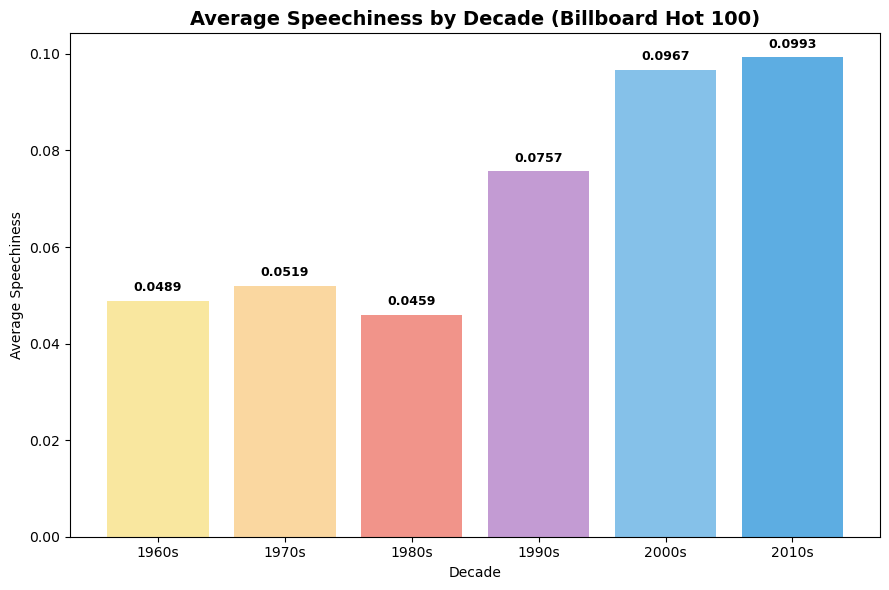

[SAVED] rq3_speechiness_decade.png

1960s avg: 0.0489, 2010s avg: 0.0993, growth: 103.1%


In [18]:
decade_colors = {
    '1960s': '#F9E79F', '1970s': '#FAD7A0', '1980s': '#F1948A',
    '1990s': '#C39BD3', '2000s': '#85C1E9', '2010s': '#5DADE2',
}
fig, ax = plt.subplots(figsize=(9, 6))
colors = [decade_colors[d] for d in speechiness_decade['decade']]
bars = ax.bar(speechiness_decade['decade'], speechiness_decade['avg_speechiness'], color=colors)
for bar, val in zip(bars, speechiness_decade['avg_speechiness']):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.002, f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')
ax.set_title('Average Speechiness by Decade (Billboard Hot 100)', fontsize=14, fontweight='bold')
ax.set_xlabel('Decade'); ax.set_ylabel('Average Speechiness')
plt.tight_layout()
plt.savefig('../Data/rq3_speechiness_decade.png', dpi=120)
plt.show()
print('[SAVED] rq3_speechiness_decade.png')

y1960s = speechiness_decade.loc[speechiness_decade['decade']=='1960s','avg_speechiness'].values[0]
y2010s = speechiness_decade.loc[speechiness_decade['decade']=='2010s','avg_speechiness'].values[0]
growth = round((y2010s - y1960s) / y1960s * 100, 1)
print(f"\n1960s avg: {y1960s}, 2010s avg: {y2010s}, growth: {growth}%")

### Step 18 — Comparison by Genre

**Inherits RQ1's already-verified limitation:** genre tags only exist for a subset of rows (14-19% coverage, uneven across decades) — this genre-level speechiness comparison carries the same limitation. Not a new problem, but worth restating for the reader.

In [19]:
genre_speech = (
    analysis_base[analysis_base['genre'].notna()]
    .groupby('genre')['speechiness'].mean().round(4)
    .sort_values(ascending=False)
    .reset_index(name='avg_speechiness')
)
genre_speech['n'] = analysis_base[analysis_base['genre'].notna()].groupby('genre').size().reindex(genre_speech['genre']).values
print(genre_speech.to_string(index=False))

  genre  avg_speechiness     n
hip hop           0.2325   895
 reggae           0.1402   159
    pop           0.0688 27617
   rock           0.0481  7507
  blues           0.0474  1644
   jazz           0.0463  1084
country           0.0372  5243


### Step 19 — Speechiness by Genre (Hip-Hop Highlighted)

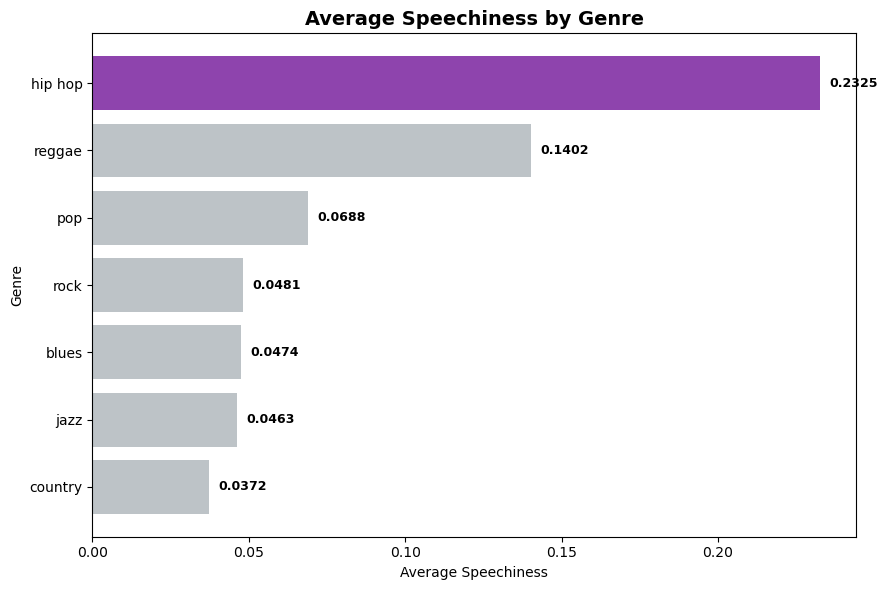

[SAVED] rq3_speechiness_genre.png


In [20]:
fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#8E44AD' if g == 'hip hop' else '#BDC3C7' for g in genre_speech['genre']]
bars = ax.barh(genre_speech['genre'], genre_speech['avg_speechiness'], color=colors)
for bar, val in zip(bars, genre_speech['avg_speechiness']):
    ax.text(val+0.003, bar.get_y()+bar.get_height()/2, f'{val:.4f}', va='center', fontsize=9, fontweight='bold')
ax.invert_yaxis()
ax.set_title('Average Speechiness by Genre', fontsize=14, fontweight='bold')
ax.set_xlabel('Average Speechiness'); ax.set_ylabel('Genre')
plt.tight_layout()
plt.savefig('../Data/rq3_speechiness_genre.png', dpi=120)
plt.show()
print('[SAVED] rq3_speechiness_genre.png')

### Step 20 — Hip-Hop vs. Other Genres, by Decade

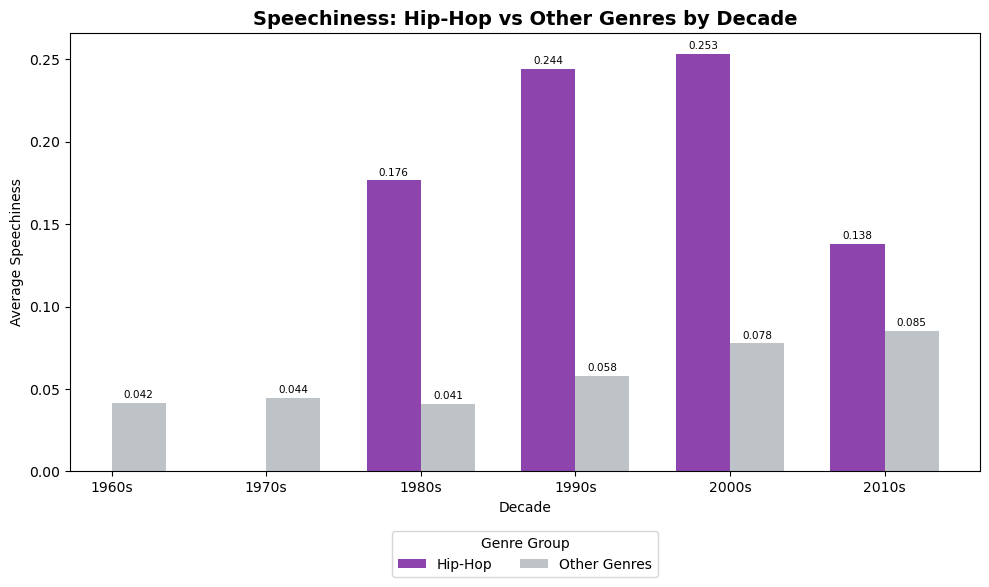

[SAVED] rq3_hiphop_vs_other.png

Hip-Hop average: 0.2325
Other Genres average: 0.0603
Ratio: 3.86x


In [21]:
hh = analysis_base[analysis_base['genre'].notna()].copy()
hh['is_hiphop'] = hh['genre'].apply(lambda g: 'Hip-Hop' if g == 'hip hop' else 'Other Genres')
hh_decade = hh.groupby(['decade', 'is_hiphop'])['speechiness'].mean().round(4).reset_index()

pivot_hh = hh_decade.pivot(index='decade', columns='is_hiphop', values='speechiness').reindex(decade_order)

fig, ax = plt.subplots(figsize=(10, 6))
x = range(len(pivot_hh.index))
width = 0.35
ax.bar([i - width/2 for i in x], pivot_hh['Hip-Hop'], width, label='Hip-Hop', color='#8E44AD')
ax.bar([i + width/2 for i in x], pivot_hh['Other Genres'], width, label='Other Genres', color='#BDC3C7')
for i, (hv, ov) in enumerate(zip(pivot_hh['Hip-Hop'], pivot_hh['Other Genres'])):
    if pd.notna(hv):
        ax.text(i - width/2, hv + 0.003, f'{hv:.3f}', ha='center', fontsize=7.5)
    if pd.notna(ov):
        ax.text(i + width/2, ov + 0.003, f'{ov:.3f}', ha='center', fontsize=7.5)
ax.set_xticks(list(x)); ax.set_xticklabels(pivot_hh.index)
ax.set_title('Speechiness: Hip-Hop vs Other Genres by Decade', fontsize=14, fontweight='bold')
ax.set_xlabel('Decade'); ax.set_ylabel('Average Speechiness')
ax.legend(title='Genre Group', loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=2)
plt.tight_layout()
plt.savefig('../Data/rq3_hiphop_vs_other.png', dpi=120)
plt.show()
print('[SAVED] rq3_hiphop_vs_other.png')

hh_avg = hh.loc[hh['is_hiphop']=='Hip-Hop', 'speechiness'].mean()
other_avg = hh.loc[hh['is_hiphop']=='Other Genres', 'speechiness'].mean()
print(f"\nHip-Hop average: {hh_avg:.4f}")
print(f"Other Genres average: {other_avg:.4f}")
print(f"Ratio: {round(hh_avg/other_avg, 2)}x")

### Step 21 — RQ3 Wrap-Up

**Speechiness roughly doubled over 60 years:** 0.0489 (1960s) → 0.0993 (2010s), a +103.1% increase. **Hip-Hop's own average, 0.2325, sits far above every other genre.**

**A statistics note worth flagging:** the "Other Genres" average has to be computed as a row-weighted (grand) mean across every song, not as a mean of each genre's own average — with genre sample sizes this unequal (reggae has 159 rows, pop has 27,700), averaging the six genre-level means together would let reggae's tiny sample distort the result as much as pop's much larger one. The correct grand-mean calculation gives Other Genres an average of **0.0603**, putting Hip-Hop's ratio at **3.86x** — a smaller, more defensible gap than a naive mean-of-means would produce.

**Limitations:**
- Genre coverage is only 14-19% (varies by decade, verified in RQ1) — the Hip-Hop-vs-other comparison rests on this subset, not the full sample
- Classification overlap: a Pop song with rap elements may not get tagged Hip-Hop, likely understating Hip-Hop's real influence — consistent with RQ1's observation that Hip-Hop's genre share only peaks at 7.6%, in the 1990s alone, which looks low
- Speechiness itself has 100% coverage and isn't affected by this limitation — a more objective, complete signal than the genre tag, which is why it's used here as a supplementary check on Hip-Hop's influence rather than relying on genre tags alone